In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import yaml

import wespeaker
from wespeaker.diar.plot_diar import plot_diarization
from wespeaker.utils.meeting_sim.room import (
    RoomConfig, ArrayConfig, MeetingRoom, create_room, compute_rirs, beamform,
    plot_room_topdown, plot_room_doa, array_angular_resolution
)

2026-05-26 12:32:34.238044: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
room_cfg = RoomConfig(length=4.0, width=3.0, height=2.4, rt60=0.4)
array_cfg = ArrayConfig(n_mics=8, spacing=0.04)
meeting_room = create_room(room_cfg, array_cfg, n_speakers=3,)
                           #configured_positions=[[1.5, 1.0, 1.5],
                           #                      [2.5, 1.0, 1.5],
                           #                      [2.0, 3.0, 1.5]])

In [4]:
meeting_room.speaker_positions

[array([1.5, 1. , 1.3]), array([2.5, 1. , 1.3]), array([2. , 2. , 1.3])]

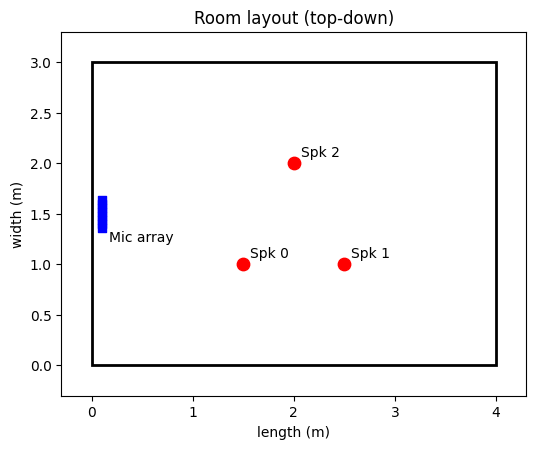

In [5]:
_ = plot_room_topdown(meeting_room)

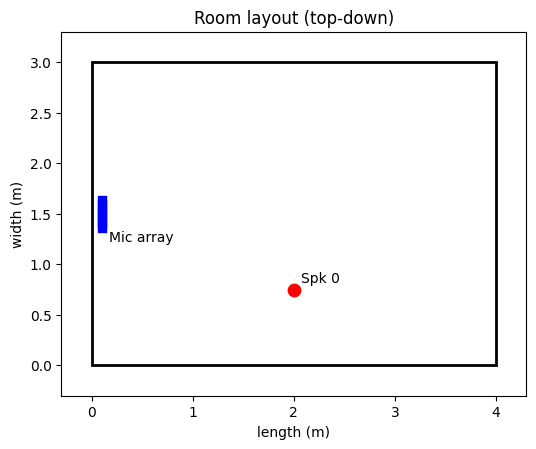

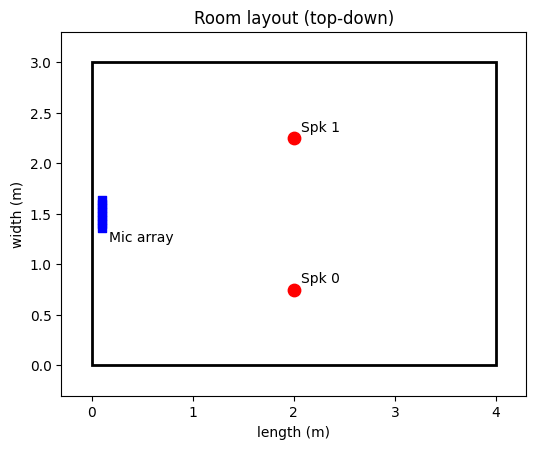

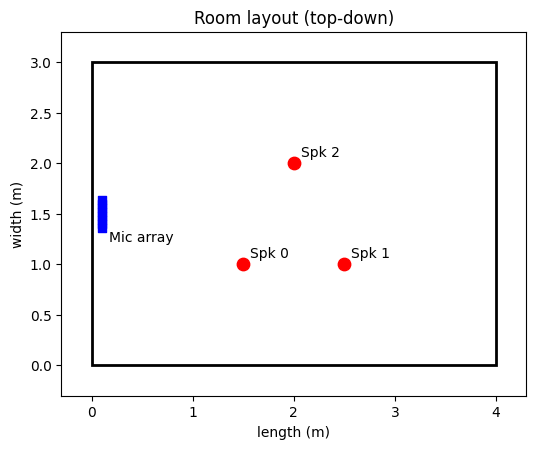

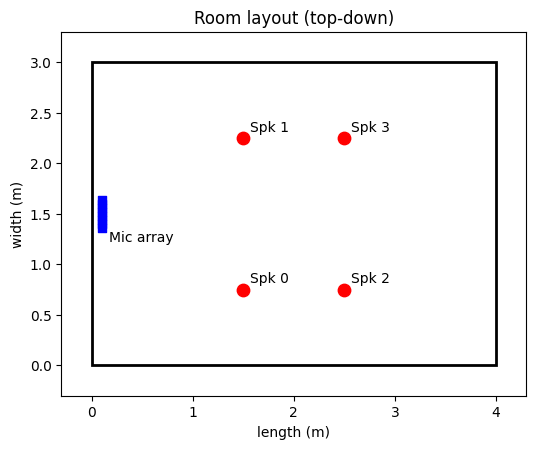

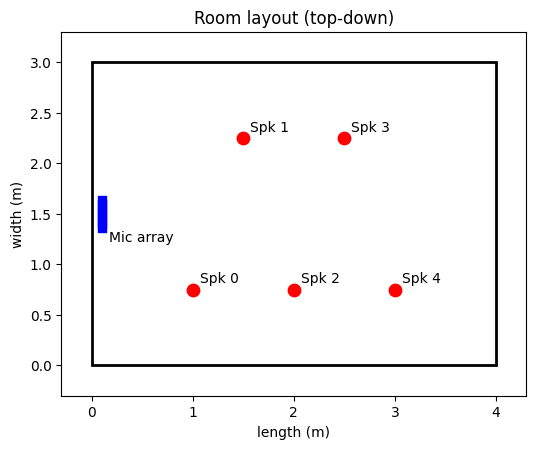

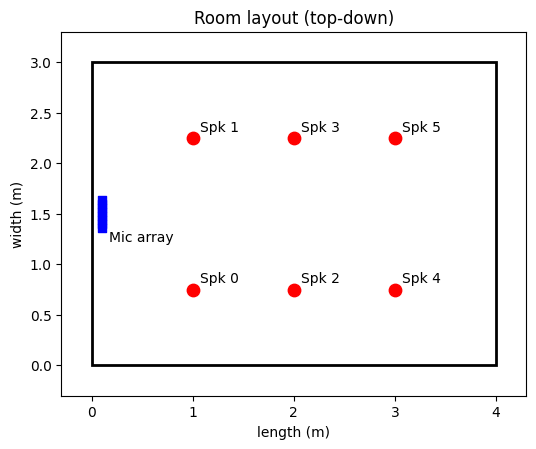

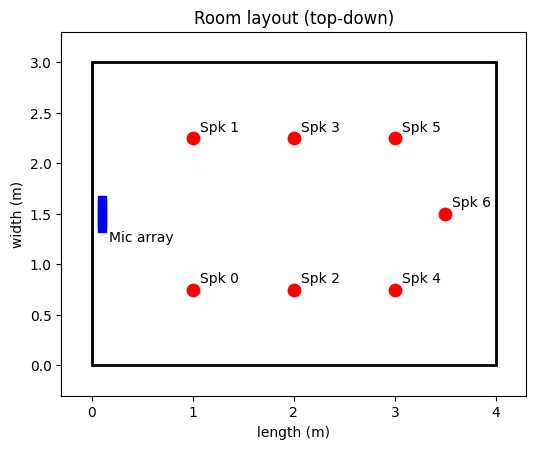

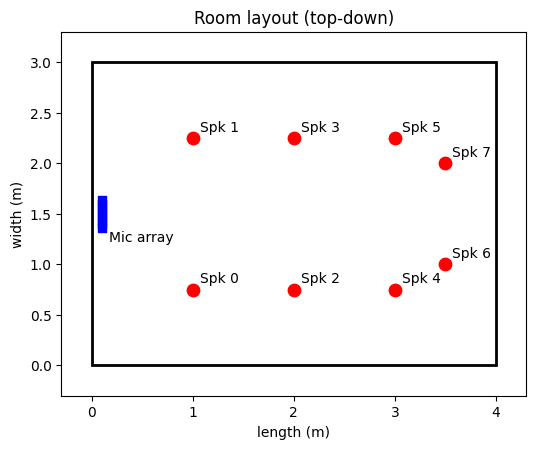

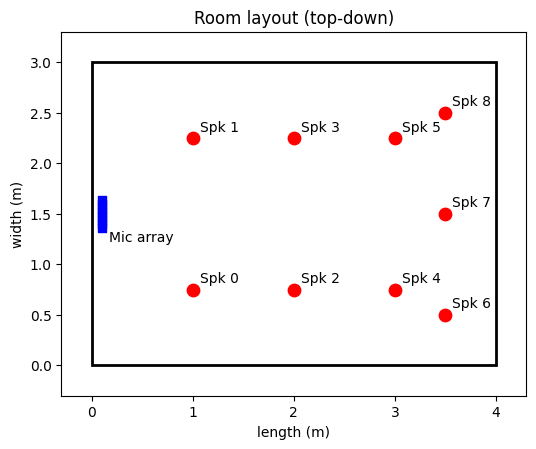

In [6]:
# check automatic speaker positioning
for i in range(1, 10):
    room = create_room(room_cfg, array_cfg, n_speakers=i)
    plot_room_topdown(room)

15.544615033931471


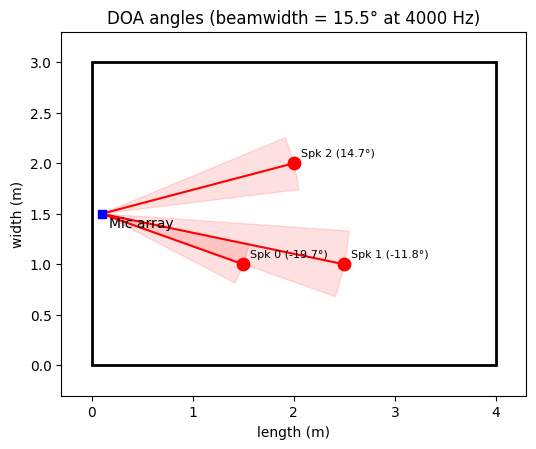

In [7]:
# angular resolution of mic array
theta = array_angular_resolution(meeting_room.array_config.n_mics,
                                 meeting_room.array_config.spacing)
print(theta)

# overlaid on room layout
fig = plot_room_doa(meeting_room)

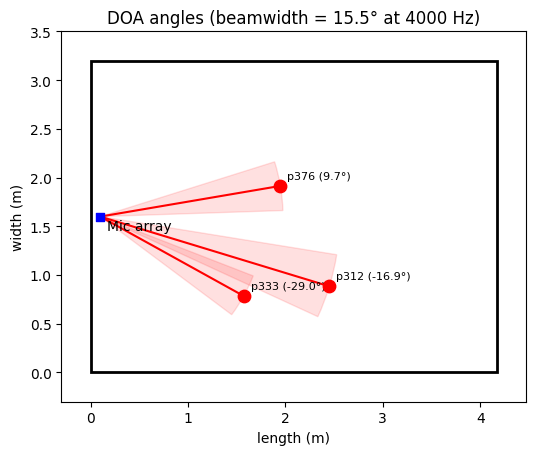

In [8]:
# from generated meeting
fig = plot_room_doa(
    metadata_path='/work/user_data/danwells/wespeaker/data-files/vctk/meeting-sim-multichannel/meetings/meeting_0008/metadata.json')

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='DOA (degrees)'>)

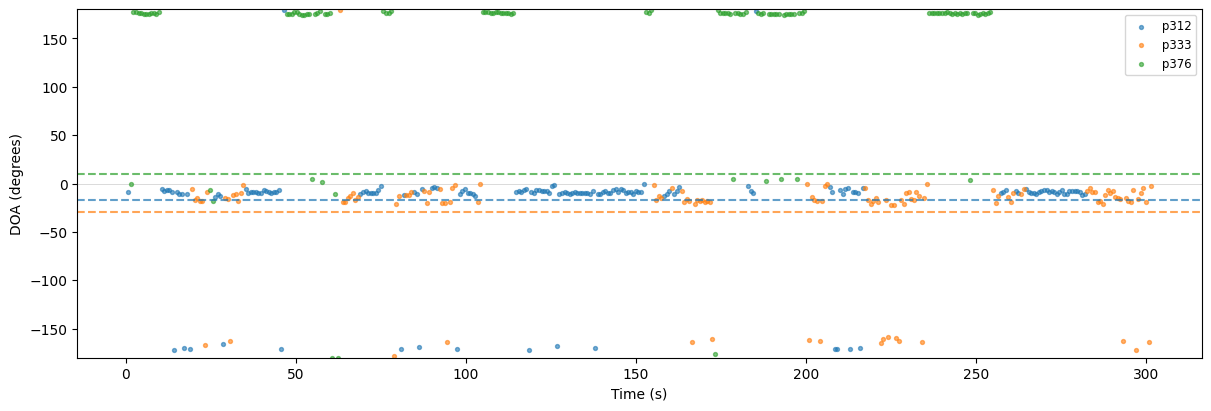

In [9]:
# DOA timeline: angle vs time, coloured by ground-truth speaker
from wespeaker.diar.beamform_diar import compute_doa_timeline
from wespeaker.diar.plot_diar import plot_doa_timeline, _wrap_angle

meeting_dir = '/work/user_data/danwells/wespeaker/data-files/vctk/meeting-sim-multichannel/meetings/meeting_0008'

doa_timeline = compute_doa_timeline(
    wav_path=f'{meeting_dir}/multichannel.wav',
    rttm_path=f'{meeting_dir}/meeting.rttm',
    metadata_path=f'{meeting_dir}/metadata.json',
)

plot_doa_timeline(doa_timeline['doa_by_speaker'], ref_azimuths=doa_timeline['ref_azimuths'])

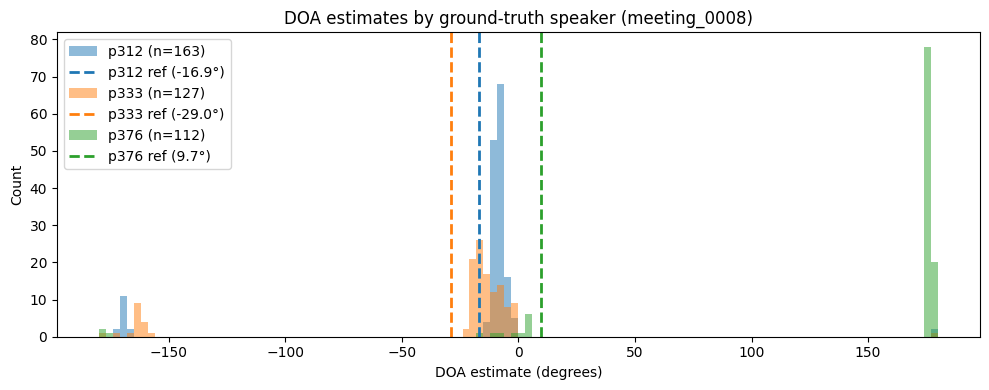

In [10]:
# plot DOA histogram
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(-180, 181, 3)
colours = plt.cm.tab10.colors

doa_by_speaker = doa_timeline['doa_by_speaker']
ref_azimuths = doa_timeline['ref_azimuths']

for i, (spk, points) in enumerate(sorted(doa_by_speaker.items())):
    doas = [_wrap_angle(p[1]) for p in points]
    ax.hist(doas, bins=bins, alpha=0.5, label=f'{spk} (n={len(doas)})',
            color=colours[i])
    ref_az = _wrap_angle(ref_azimuths[spk])
    ax.axvline(ref_az, color=colours[i], ls='--', lw=2,
               label=f'{spk} ref ({ref_az:.1f}°)')

ax.set_xlabel('DOA estimate (degrees)')
ax.set_ylabel('Count')
ax.set_title('DOA estimates by ground-truth speaker (meeting_0008)')
ax.legend()
plt.tight_layout()

(<Figure size 1200x380 with 2 Axes>,
 array([<Axes: ylabel='RMS'>, <Axes: xlabel='Time (s)'>], dtype=object))

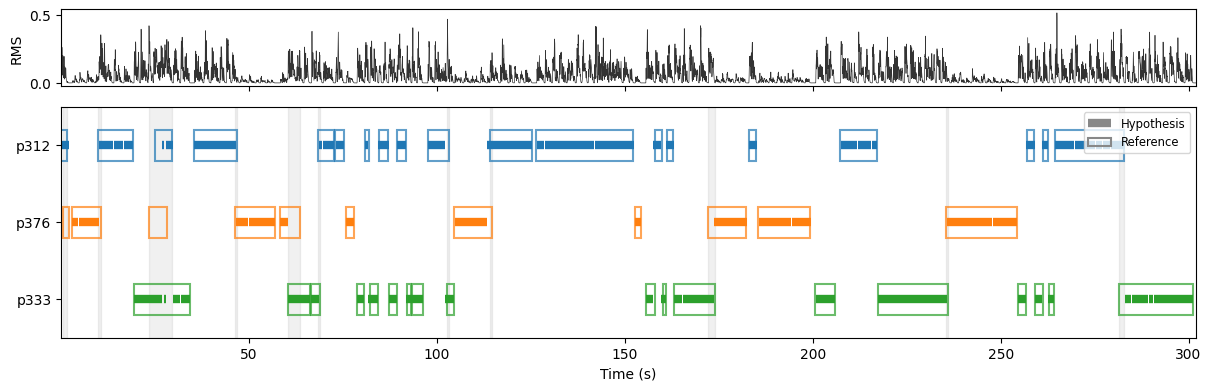

In [11]:
# plot diarization timeline (from embeddings)
vctk_dir = '/work/user_data/danwells/wespeaker/data-files/vctk/meeting-sim'
exp_dir = f'{vctk_dir}/exp/win_1.5_stride_0.5_system_sad'

meeting_id = 'meeting_0008'

plot_diarization(
    hyp_rttm=f'{exp_dir}/spectral_cluster/system_sad_rttm',
    ref_rttm=f'{vctk_dir}/all_meetings.rttm',
    utt_id=meeting_id,
    wav_path=f'{vctk_dir}/meetings/{meeting_id}/mixed.wav',
    #start_time=0, end_time=90,
    show_overlap=True, monochrome=False,
    ref_style='hollow', # field, hollow, line
)

(<Figure size 1200x630 with 3 Axes>,
 array([<Axes: ylabel='RMS'>, <Axes: >,
        <Axes: xlabel='Time (s)', ylabel='DOA (degrees)'>], dtype=object))

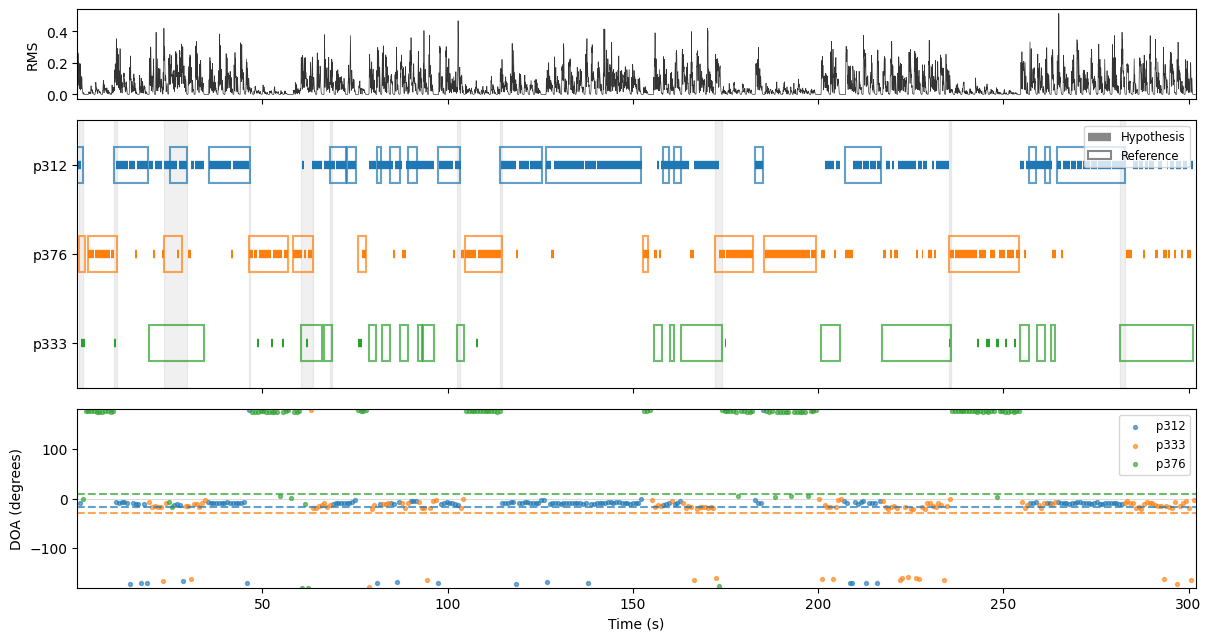

In [12]:
# plot diarization timeline with doa estimates (from beamforming)
vctk_dir = '/work/user_data/danwells/wespeaker/data-files/vctk/meeting-sim-multichannel'
exp_dir = f'{vctk_dir}/exp/beamform_supervised_win_1.5_stride_0.5_system_sad'

meeting_id = 'meeting_0008'

doa_timeline = compute_doa_timeline(
    wav_path=f'{vctk_dir}/meetings/{meeting_id}/multichannel.wav',
    rttm_path=f'{vctk_dir}/meetings/{meeting_id}/meeting.rttm',
    metadata_path=f'{vctk_dir}/meetings/{meeting_id}/metadata.json',
)

plot_diarization(
    hyp_rttm=f'{exp_dir}/system_sad_rttm',
    ref_rttm=f'{vctk_dir}/all_meetings.rttm',
    utt_id=meeting_id,
    wav_path=f'{vctk_dir}/meetings/{meeting_id}/mixed.wav',
    doa_timeline=doa_timeline,
    #start_time=0, end_time=90,
    show_overlap=True, monochrome=False,
    ref_style='hollow', # field, hollow, line
)

## room devices test audio

(<Figure size 1200x620 with 2 Axes>,
 array([<Axes: ylabel='RMS'>, <Axes: xlabel='Time (s)'>], dtype=object))

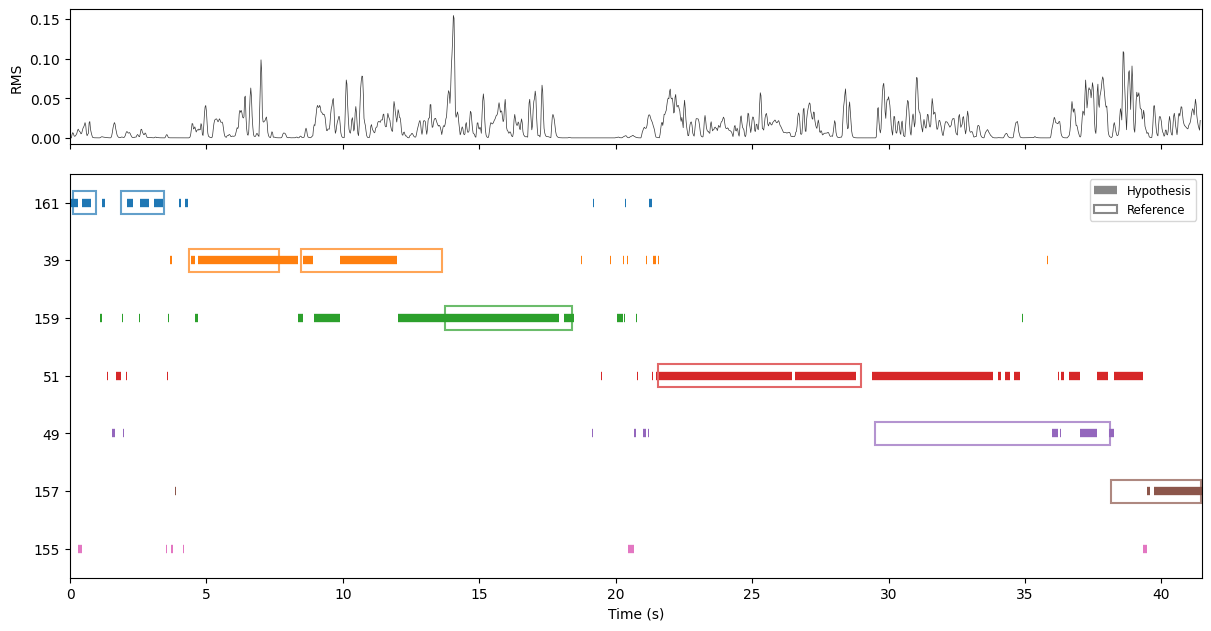

In [13]:
# beamforming (no face filtering)
vctk_dir = '/work/user_data/danwells/wespeaker/data-files/room_devices'
exp_dir = f'{vctk_dir}/output'

meeting_id = 'audio_rec2'

plot_diarization(
    hyp_rttm=f'{exp_dir}/{meeting_id}.rttm',
    ref_rttm=f'{vctk_dir}/reference.rttm',
    utt_id=meeting_id,
    wav_path=f'{exp_dir}/{meeting_id}_aligned.wav',
    start_time=0, #end_time=90,
    show_overlap=True, monochrome=False,
    ref_style='hollow', # field, hollow, line
)

(<Figure size 1200x620 with 2 Axes>,
 array([<Axes: ylabel='RMS'>, <Axes: xlabel='Time (s)'>], dtype=object))

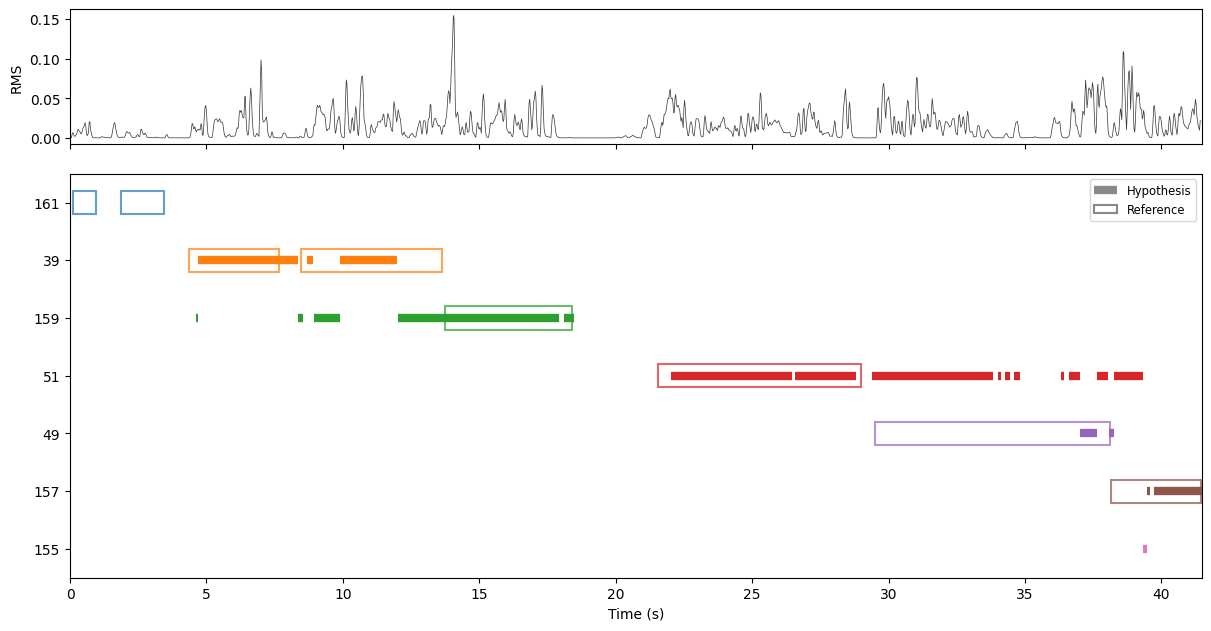

In [14]:
# beamforming (face-only frames)
vctk_dir = '/work/user_data/danwells/wespeaker/data-files/room_devices'
exp_dir = f'{vctk_dir}/output'

meeting_id = 'audio_rec2'

plot_diarization(
    hyp_rttm=f'{exp_dir}/{meeting_id}_f.rttm',
    ref_rttm=f'{vctk_dir}/reference.rttm',
    utt_id=meeting_id,
    wav_path=f'{exp_dir}/{meeting_id}_aligned.wav',
    start_time=0, #end_time=45,
    show_overlap=True, monochrome=False,
    ref_style='hollow', # field, hollow, line
)

(<Figure size 1200x360 with 1 Axes>, <Axes: xlabel='Time (s)'>)

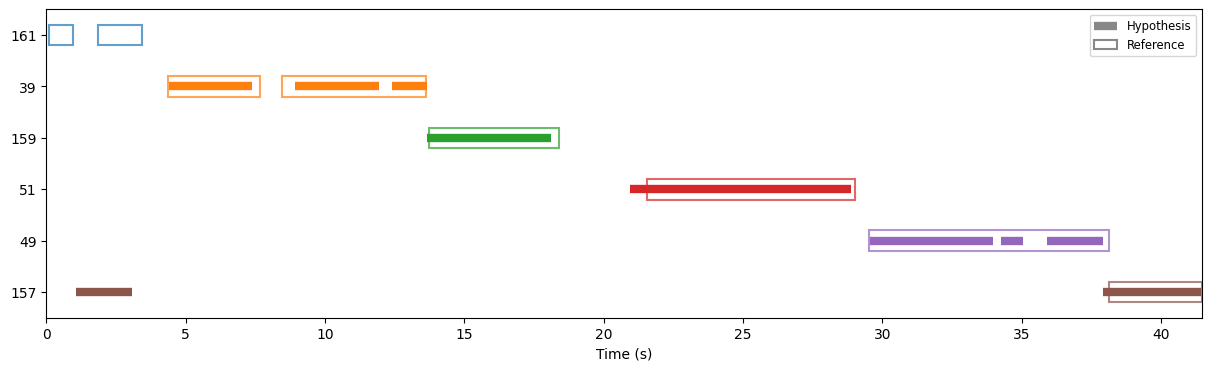

In [15]:
# clustered speaker embeddings
vctk_dir = '/work/user_data/danwells/wespeaker/data-files/room_devices'
exp_dir = f'{vctk_dir}/exp/spectral_cluster_win_1.5_stride_0.5_system_sad'

meeting_id = 'audio_rec2'

plot_diarization(
    hyp_rttm=f'{exp_dir}/system_sad_rttm',
    ref_rttm=f'{vctk_dir}/reference.rttm',
    utt_id=meeting_id,
    #wav_path=f'{exp_dir}/{meeting_id}_aligned.wav',
    start_time=0, #end_time=45,
    show_overlap=True, monochrome=False,
    ref_style='hollow', # field, hollow, line
)